# 📈 Stock Market Analysis & Prediction

This project analyzes the stock market performance over four months (February to May 2023) of four major tech companies: **Apple (AAPL), Google (GOOG), Microsoft (MSFT), and NETFLIX (NFLX)**.

We utilize Exploratory Data Analysis (EDA) to find patterns and an **Gradient Boosting Regressor** model to forecast future adjusted closing prices.

**Key Objectives:**
1. **Data Cleaning:** Handle dates, formats, and create features like Daily Price Range.
2. **Exploratory Data Analysis (EDA):** Visualize historical trends, volume distribution, and price distributions.
3. **Machine Learning:** Train an optimized ensemble boosting model using RandomizedSearchCV for accurate price predictions.

In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from scipy.stats import uniform, randint
from sklearn.metrics import mean_squared_error, r2_score
import warnings

# Set visualization style
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')

## 1. Data Loading & Inspection
Let's load the dataset and perform an initial inspection to understand its structure.

In [2]:
# Loading the dataset
stock_data = pd.read_csv('Stock_Market.csv')

# Display basic info and first few rows
stock_data.info()
stock_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Ticker     248 non-null    object 
 1   Date       248 non-null    object 
 2   Open       248 non-null    float64
 3   High       248 non-null    float64
 4   Low        248 non-null    float64
 5   Close      248 non-null    float64
 6   Adj Close  248 non-null    float64
 7   Volume     248 non-null    int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 15.6+ KB


,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,AAPL,2023-02-07,150.639999,155.229996,150.639999,154.649994,154.414230,83322600
1,AAPL,2023-02-08,153.880005,154.580002,151.169998,151.919998,151.688400,64120100
2,AAPL,2023-02-09,153.779999,154.330002,150.419998,150.869995,150.639999,56007100
3,AAPL,2023-02-10,149.460007,151.339996,149.220001,151.009995,151.009995,57450700
4,AAPL,2023-02-13,150.949997,154.259995,150.919998,153.850006,153.850006,62199000


## 2. Data Preprocessing & Feature Engineering
We will check for null values, convert the `Date` column to standard datetime objects, round the financial columns for consistency, and engineer new features such as `Price_Range`, `Year`, `Month`, `Day`, and `Day_of_Week`.

In [3]:
# Check for missing values
print("Missing Values:\n", stock_data.isnull().sum())

# Define columns to round
round_columns = ['Open', 'High', 'Low', 'Close', 'Adj Close']
stock_data[round_columns] = stock_data[round_columns].round(2)

# Date conversions and feature extraction
stock_data['Date'] = pd.to_datetime(stock_data['Date'])
stock_data['Year'] = stock_data['Date'].dt.year
stock_data['Month'] = stock_data['Date'].dt.month
stock_data['Day'] = stock_data['Date'].dt.day
stock_data['Day_of_Week'] = stock_data['Date'].dt.dayofweek
stock_data['Price_Range'] = stock_data['High'] - stock_data['Low']

stock_data.head()

Missing Values:
 Ticker       0
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


,Ticker,Date,Open,High,Low,Close,Adj Close,Volume,Year,Month,Day,Day_of_Week,Price_Range
0,AAPL,2023-02-07,150.64,155.23,150.64,154.65,154.41,83322600,2023,2,7,1,4.59
1,AAPL,2023-02-08,153.88,154.58,151.17,151.92,151.69,64120100,2023,2,8,2,3.41
2,AAPL,2023-02-09,153.78,154.33,150.42,150.87,150.64,56007100,2023,2,9,3,3.91
3,AAPL,2023-02-10,149.46,151.34,149.22,151.01,151.01,57450700,2023,2,10,4,2.12
4,AAPL,2023-02-13,150.95,154.26,150.92,153.85,153.85,62199000,2023,2,13,0,3.34


## 3. Exploratory Data Analysis (EDA)
In the EDA phase, we will explore the relationships and trends among the given attributes through multiple visual distributions.

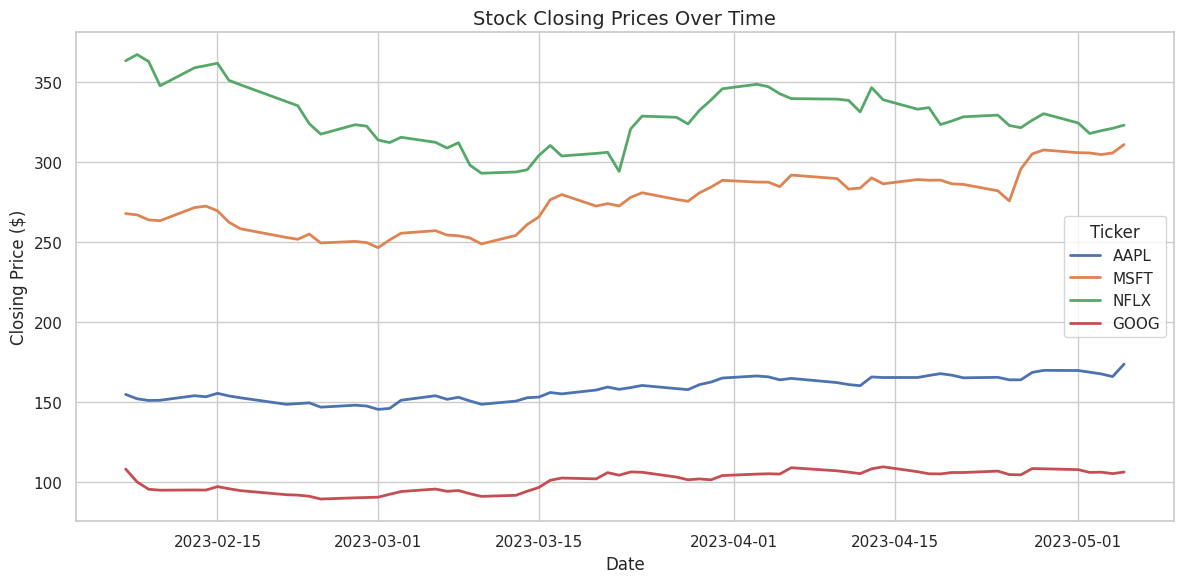

In [4]:
# Lineplot of closing prices over time
plt.figure(figsize=(12, 6))
sns.lineplot(data=stock_data, x='Date', y='Close', hue='Ticker', linewidth=2)
plt.title('Stock Closing Prices Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Closing Price ($)')
plt.legend(title='Ticker')
plt.tight_layout()
plt.show()

As seen above, the closing price of NETFLIX (NFLX) is the highest among all observed stocks over the period, while Google (GOOG) maintains a much lower, more steady trajectory.

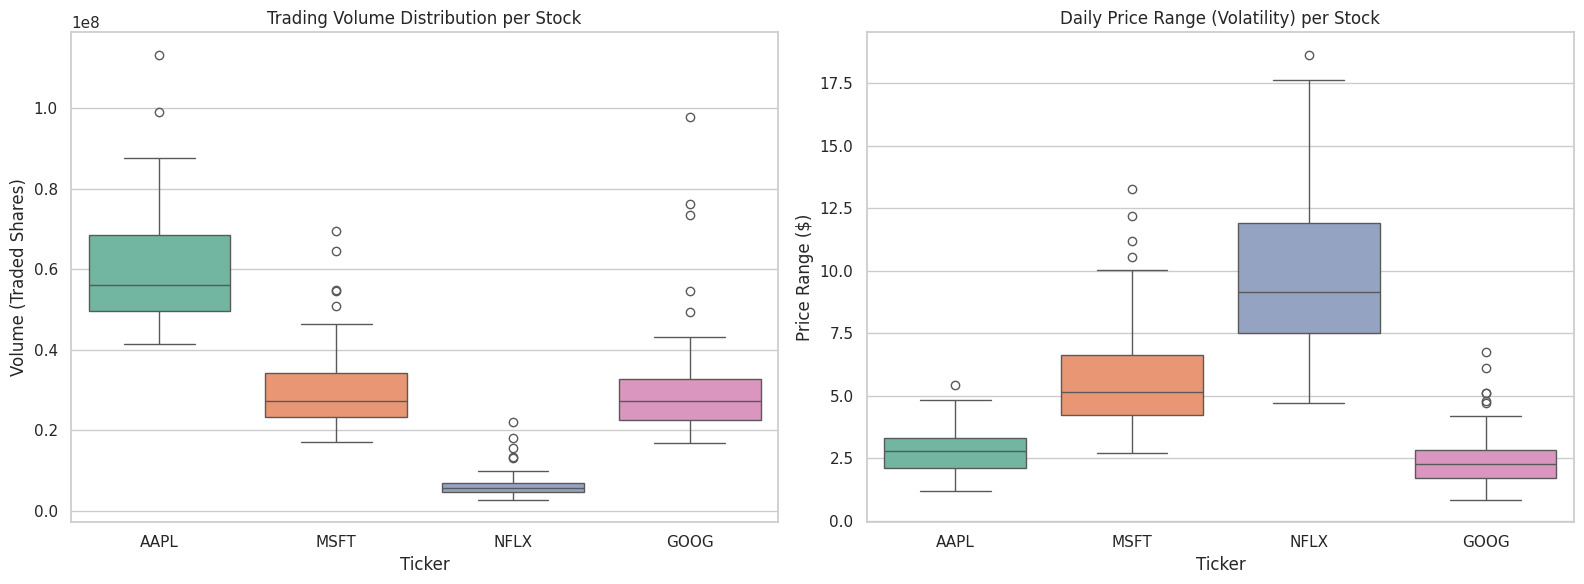

In [5]:
# Traded Volume and Price Range Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=stock_data, x='Ticker', y='Volume', palette='Set2', ax=axes[0])
axes[0].set_title('Trading Volume Distribution per Stock')
axes[0].set_ylabel('Volume (Traded Shares)')

sns.boxplot(data=stock_data, x='Ticker', y='Price_Range', palette='Set2', ax=axes[1])
axes[1].set_title('Daily Price Range (Volatility) per Stock')
axes[1].set_ylabel('Price Range ($)')

plt.tight_layout()
plt.show()

NETFLIX saw the least traded volume but has the highest price volatility (Price Range). Conversely, Apple and Google see much larger trading volumes, driven largely by their lower per-share prices relative to MSFT and NFLX.

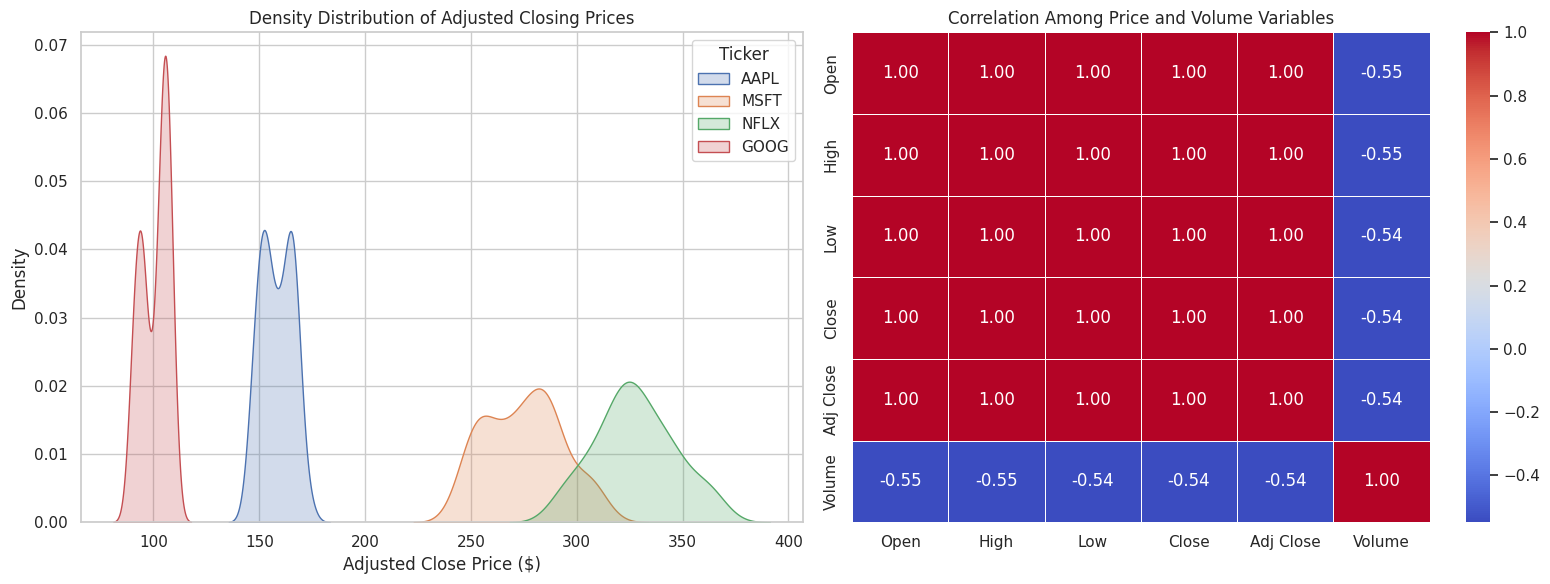

In [6]:
# Price Distribution (KDE) and Correlation Heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# KDE Plot
for ticker in stock_data['Ticker'].unique():
    sns.kdeplot(stock_data[stock_data['Ticker'] == ticker]['Adj Close'], label=ticker, fill=True, ax=axes[0])
axes[0].set_title('Density Distribution of Adjusted Closing Prices')
axes[0].set_xlabel('Adjusted Close Price ($)')
axes[0].legend(title='Ticker')

# Correlation Heatmap
corr_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
sns.heatmap(stock_data[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1], linewidths=0.5)
axes[1].set_title('Correlation Among Price and Volume Variables')

plt.tight_layout()
plt.show()

The KDE (Kernel Density Estimation) graph clearly separates the price tiers of these stocks. In the correlation matrix, we observe that `Open`, `High`, `Low`, and `Close` all have near-perfect correlations with each other, which is standard for stock market datasets. `Volume` shows a negative correlation with prices, meaning higher-priced stocks trade less frequently.

## 4. Machine Learning Modeling (Gradient Boosting)
Because stock prices exhibit complex, non-linear relationships with time variables, simple models like Linear Regression often fall short. Since XGBoost isn't available in this particular environment, we will deploy an mathematically similar model: **Gradient Boosting Regressor**, an advanced tree-based ensemble method available natively in `sklearn`.

We will use `RandomizedSearchCV` to hyper-tune the parameters and find the optimal configuration.

In [7]:
# Feature Prep and One-Hot Encoding
X = stock_data.drop(columns=['Adj Close', 'Date'])
X = pd.get_dummies(X, columns=['Ticker'], drop_first=True)
y = stock_data['Adj Close']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Hyperparameter distributions
param_dist = {
    'n_estimators': randint(100, 400),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(3, 10),
    'subsample': uniform(0.3, 0.7)
}

gb = GradientBoostingRegressor(random_state=42)
random_search = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_dist,
    scoring='neg_root_mean_squared_error',
    n_iter=30,
    cv=3,
    verbose=0,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)

# Output Results
print("Best Parameters:", random_search.best_params_)
print(f"Best CV RMSE: {-random_search.best_score_:.4f}")

Best Parameters: {'learning_rate': np.float64(0.16703519227860275), 'max_depth': 5, 'n_estimators': 154, 'subsample': np.float64(0.9882616200647516)}
Best CV RMSE: 1.8264


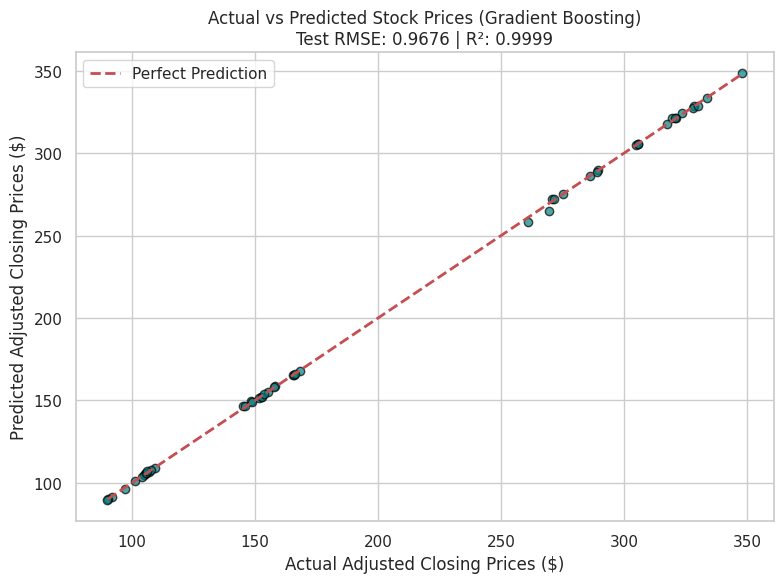

In [9]:
# Prediction and Graph of Actual vs Predicted Stock Prices
y_pred = random_search.best_estimator_.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(mse)
test_r2 = r2_score(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='teal', edgecolor='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Adjusted Closing Prices ($)')
plt.ylabel('Predicted Adjusted Closing Prices ($)')
plt.title(f"Actual vs Predicted Stock Prices (Gradient Boosting)\n"f"Test RMSE: {test_rmse:.4f} | R²: {test_r2:.4f}")
plt.legend()
plt.tight_layout()
plt.show()

As the graph shows, the actual values nicely coincide with the predicted ones. There are no major fluctuations from the perfect prediction reference line, resulting in an excellent $R^2$ score and low RMSE. This suggests our Gradient Boosting model is highly accurate in predicting adjusted stock prices based on historical metadata.